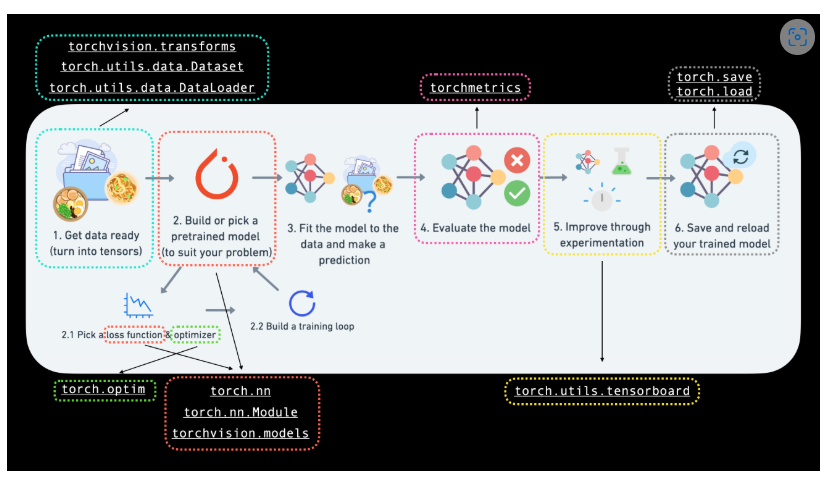

## 0. Computer vision libraries in PyTorch

In [1]:
# Import Pytorch
import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import models, datasets
from torchvision.transforms import ToTensor

# Import other libraries
import matplotlib.pyplot as plt

In [2]:
# Check version of Pytorch
print("Pytorch version:", torch.__version__)
# Check version of torchvision
print("Torchvision version:", torchvision.__version__)

Pytorch version: 2.7.0+cu126
Torchvision version: 0.22.0+cu126


In [3]:
# Setup device agnostic code
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## 1. Getting a dataset

In [4]:
# Setup training data
train_data = datasets.FashionMNIST(
    root="data", # where to download data to?
    train=True, # get training data
    download=True, # download data if it doesn't exist on disk
    transform=ToTensor(), # images come as PIL format, we want to turn into Torch tensors
    target_transform=None # you can transform labels as well
)

# Setup testing data
test_data = datasets.FashionMNIST(
    root="data",
    train=False, # get test data
    download=True,
    transform=ToTensor()
)

In [5]:
# See first training sample
image, label = train_data[0]
# image, label

### 1.1 Input and output shapes of a computer vision model

In [6]:
# What's the shape of the image?
print("Image shape:", image.shape)

Image shape: torch.Size([1, 28, 28])


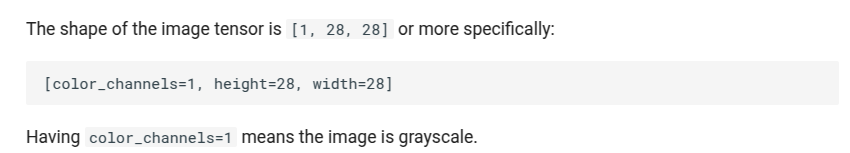

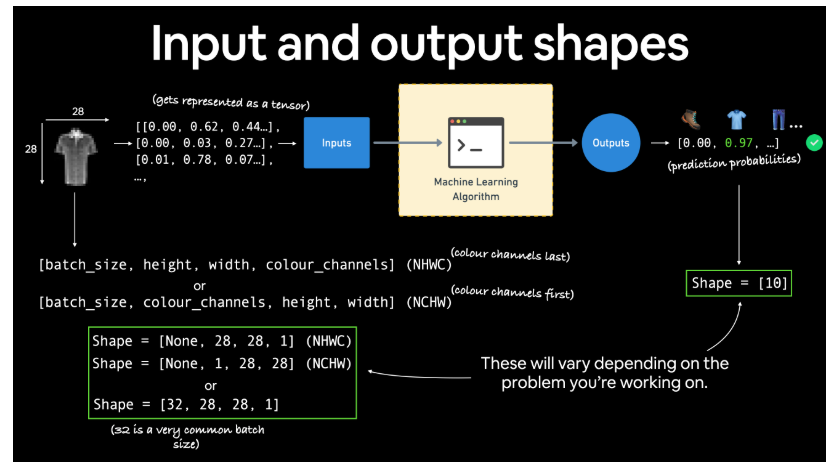

In [7]:
# How many samples are there? 
len(train_data.data), len(train_data.targets), len(test_data.data), len(test_data.targets)

(60000, 60000, 10000, 10000)

In [8]:
# How many classes are there?
class_names = train_data.classes
print("Class names:", class_names)

Class names: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


### 1.2 Visualizing our data

Image shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

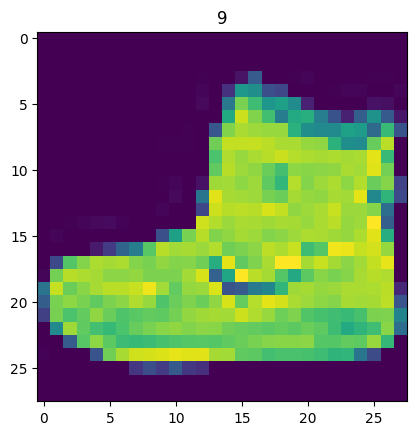

In [9]:
import matplotlib.pyplot as plt
image, label = train_data[0]
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze()) # image shape is [1, 28, 28] (colour channels, height, width)
plt.title(label)

Text(0.5, 1.0, 'Ankle boot')

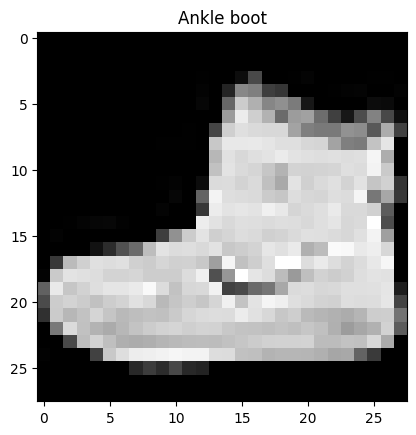

In [10]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])

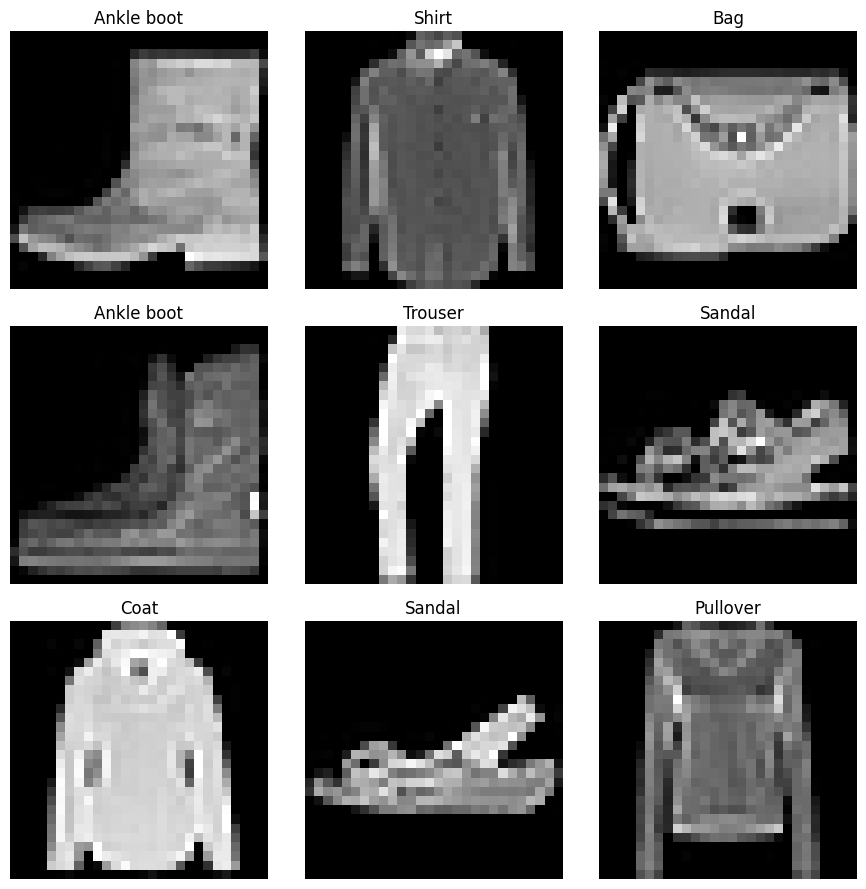

In [11]:
# Plotting a few images
torch.manual_seed(42) # for reproducibility
# Set up figure
plt.figure(figsize=(9, 9))
# Loop through 9 random samples
for i in range(9):
    # Randomly select an index
    rand_idx = torch.randint(0, len(train_data), size=[1]).item()
    # Get the image and label
    image, label = train_data[rand_idx]
    # Plot the image
    plt.subplot(3, 3, i+1)
    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False)
# Show the plot
plt.tight_layout()
plt.show()

## 2. Prepare DataLoader

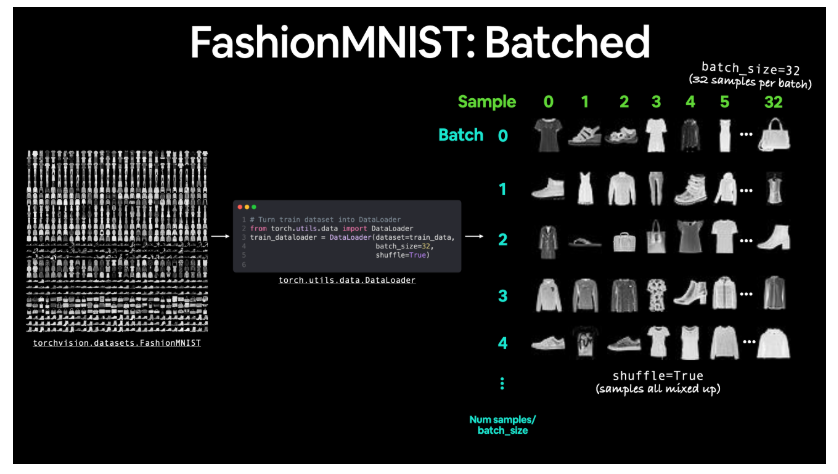

In [13]:
from torch.utils.data import DataLoader

In [14]:
# Setup the batch size hyperparameter
BATCH_SIZE = 32

# Turn datasets into iterables (batches)
train_dataloader = DataLoader(train_data, # dataset to turn into iterable
    batch_size=BATCH_SIZE, # how many samples per batch? 
    shuffle=True # shuffle data every epoch?
)

test_dataloader = DataLoader(test_data,
    batch_size=BATCH_SIZE,
    shuffle=False # don't necessarily have to shuffle the testing data
)

# Let's check out what we've created
print(f"Dataloaders: {train_dataloader, test_dataloader}") 
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7681b59bf290>, <torch.utils.data.dataloader.DataLoader object at 0x7681b5af30d0>)
Length of train dataloader: 1875 batches of 32
Length of test dataloader: 313 batches of 32


In [15]:
# DataLoader iterators
print("First batch of training data:")
train_features, train_labels = next(iter(train_dataloader))
print(f"Features shape: {train_features.shape}")
print(f"Labels shape: {train_labels.shape}")

First batch of training data:
Features shape: torch.Size([32, 1, 28, 28])
Labels shape: torch.Size([32])


Text(0.5, 1.0, 'Sandal')

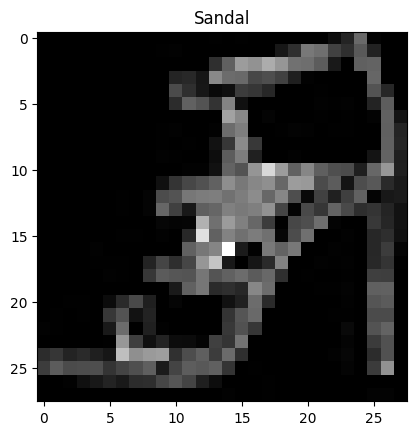

In [16]:
# Show Sample
plt.imshow(train_features[0].squeeze(), cmap="gray")
plt.title(class_names[train_labels[0]])

## 3. Model 0: Build a baseline model

In [17]:
# Create a flatten layer
flatten_model = nn.Flatten() # all nn modules function as a model (can do a forward pass)

# Get a single sample
x = train_features[0]

# Flatten the sample
output = flatten_model(x) # perform forward pass

# Print out what happened
print(f"Shape before flattening: {x.shape} -> [color_channels, height, width]")
print(f"Shape after flattening: {output.shape} -> [color_channels, height*width]")

# Try uncommenting below and see what happens
#print(x)
#print(output)

Shape before flattening: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Shape after flattening: torch.Size([1, 784]) -> [color_channels, height*width]


The `nn.Flatten()` layer transforms our input shape from [color_channels, height, width] to [color_channels, height*width], flattening the 2D image into a 1D vector for processing by linear layers.

In [18]:
# Create a baseline model
class FashionMNISTModelV0(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        # Define model layers
        self.model = nn.Sequential(
            nn.Flatten(), # flatten the input
            nn.Linear(in_features=input_shape, out_features=hidden_units), # first layer
            # Apply Batch Normalization
            nn.BatchNorm1d(hidden_units), # batch normalization
            nn.ReLU(), # activation function
            nn.Dropout(0.2), # dropout layer
            nn.Linear(in_features=hidden_units, out_features=output_shape), # second layer
            nn.ReLU() # activation function
        )
    def forward(self, x):
        return self.model(x)

In [19]:
torch.manual_seed(42)

# Need to setup model with input parameters
model_0 = FashionMNISTModelV0(input_shape=784, # one for every pixel (28x28)
    hidden_units=10, # how many units in the hidden layer
    output_shape=len(class_names) # one for every class
)
model_0.to("cpu") # keep model on CPU to begin with 

FashionMNISTModelV0(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.2, inplace=False)
    (5): Linear(in_features=10, out_features=10, bias=True)
    (6): ReLU()
  )
)

### 3.1 Setup loss, optimizer and evaluation metrics

In [20]:
# Import accuracy metric
from helper_functions import accuracy_fn # Note: could also use torchmetrics.Accuracy(task = 'multiclass', num_classes=len(class_names)).to(device)

In [21]:
# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss() # this is also called "criterion"/"cost function" in some places
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1, weight_decay=0.01) # stochastic gradient descent

### 3.2 Creating a training loop and training a model on batches of data

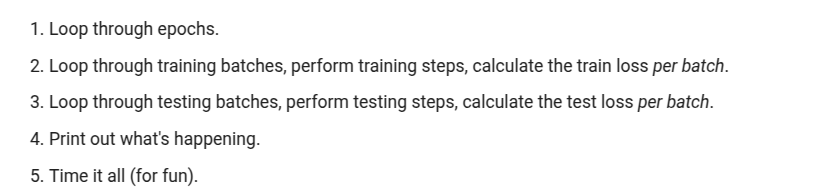

In [22]:
from timeit import default_timer as timer 
def print_train_time(start: float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [23]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

# set the seed for reproducibility
torch.manual_seed(42)
train_time_on_cpu_start = timer()

# Setup epochs
epochs = 3

# Creating the taining and testing loop

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    # Training
    model_0.train() # put model in training mode
    train_loss = 0

    for batch, (X, y) in enumerate(train_dataloader):
        # Send data to GPU if available
        X, y = X.to("cpu"), y.to("cpu")
        # 1. Forward pass
        y_pred = model_0(X) # make predictions
        # 2. Calculate loss/accuracy
        loss = loss_fn(y_pred, y) # calculate loss
        train_loss += loss.item() # accumulate loss
        # 3. Optimizer zero grad
        optimizer.zero_grad() # zero gradients
        # 4. Loss backwards
        loss.backward() # backpropagation
        # 5. Optimizer step
        optimizer.step() # update weights
    # Calculate train loss and accuracy
    train_loss /= len(train_dataloader) # average loss
    y_pred_labels = torch.argmax(y_pred, dim=1) # get predicted labels
    train_acc = accuracy_fn(y_true=y.cpu(), y_pred=y_pred_labels.cpu()) # calculate accuracy
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")
    # Testing
    model_0.eval() # put model in evaluation mode
    test_loss = 0
    test_acc = 0
    with torch.inference_mode(): # turn off gradients
        for batch, (X, y) in enumerate(test_dataloader):
            # Send data to GPU if available
            X, y = X.to("cpu"), y.to("cpu")
            # 1. Forward pass
            test_pred = model_0(X) # make predictions
            # 2. Calculate loss/accuracy
            loss = loss_fn(test_pred, y) # calculate loss
            test_loss += loss.item() # accumulate loss
            test_pred_labels = torch.argmax(test_pred, dim=1) # get predicted labels
            test_acc += accuracy_fn(y_true=y.cpu(), y_pred=test_pred_labels.cpu()) # calculate accuracy
        test_loss /= len(test_dataloader) # average loss
        test_acc /= len(test_dataloader) # average accuracy
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%")

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 0.90965 | Train accuracy: 78.12%
Test loss: 0.65217 | Test accuracy: 79.33%
Epoch: 1
---------
Train loss: 0.81897 | Train accuracy: 62.50%
Test loss: 0.63095 | Test accuracy: 80.13%
Epoch: 2
---------
Train loss: 0.80419 | Train accuracy: 84.38%
Test loss: 0.61268 | Test accuracy: 80.12%


## 4. Make predictions and get Model 0 results

In [24]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module, 
               data_loader: torch.utils.data.DataLoader, 
               loss_fn: torch.nn.Module, 
               accuracy_fn):
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            # Make predictions with the model
            y_pred = model(X)
            
            # Accumulate the loss and accuracy values per batch
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, 
                                y_pred=y_pred.argmax(dim=1)) # For accuracy, need the prediction labels (logits -> pred_prob -> pred_labels)
        
        # Scale loss and acc to find the average loss/acc per batch
        loss /= len(data_loader)
        acc /= len(data_loader)
        
    return {"model_name": model.__class__.__name__, # only works when model was created with a class
            "model_loss": loss.item(),
            "model_acc": acc}

# Calculate model 0 results on test dataset
model_0_results = eval_model(model=model_0, data_loader=test_dataloader,
    loss_fn=loss_fn, accuracy_fn=accuracy_fn
)
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.6126813888549805,
 'model_acc': 80.12180511182109}

## Model 2: Building a Convolutional Neural Network (CNN)

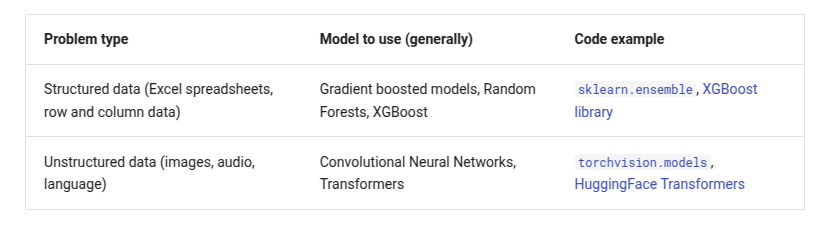

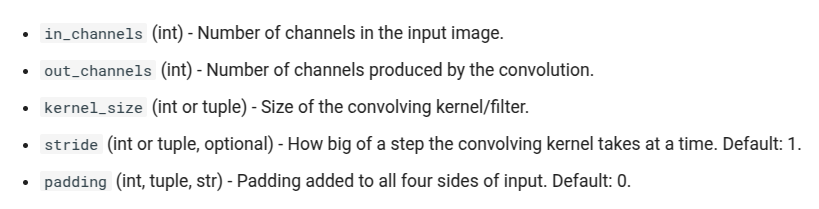

In [30]:
# CNN Model with better architecture and training stability
class FashionMNISTModelV2(nn.Module):
    def __init__(self, hidden_units: int, output_shape: int):
        super().__init__()
        
        # Convolutional feature extractor with batch normalization
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1),  # [28x28] → [28x28]
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, stride=1, padding=1),  # [28x28] → [28x28]
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # [28x28] → [14x14]
            nn.Dropout2d(0.25)
        )
        
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),  # [14x14] → [14x14]
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1, padding=1),  # [14x14] → [14x14]
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # [14x14] → [7x7]
            nn.Dropout2d(0.25)
        )
        
        # Fully connected classifier
        self.fc_layer = nn.Sequential(
            nn.Flatten(),  # [64, 7, 7] → 3136
            nn.Linear(in_features=64 * 7 * 7, out_features=hidden_units),
            nn.BatchNorm1d(hidden_units),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(in_features=hidden_units, out_features=hidden_units // 2),
            nn.BatchNorm1d(hidden_units // 2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(in_features=hidden_units // 2, out_features=output_shape)  # logits output
        )
        
        # Initialize weights properly
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.fc_layer(x)
        return x

In [32]:
# Create improved model instance
torch.manual_seed(42)

model_2 = FashionMNISTModelV2(
    hidden_units=128,  # Increased hidden layer size
    output_shape=len(class_names)  # 10 classes in FashionMNIST
).to(device)

print(f"Model created and moved to: {device}")
print(f"Model: {model_2}")

# Count parameters
total_params = sum(p.numel() for p in model_2.parameters())
trainable_params = sum(p.numel() for p in model_2.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Model created and moved to: cpu
Model: FashionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=

In [33]:
# Setup improved loss function and optimizer
loss_fn = nn.CrossEntropyLoss()

# Use Adam optimizer with a lower learning rate
optimizer_v2 = torch.optim.Adam(params=model_2.parameters(), 
                               lr=0.001,  # Much lower learning rate
                               betas=(0.9, 0.999),
                               weight_decay=1e-4)  # Lower weight decay

# Add learning rate scheduler for better convergence
from torch.optim.lr_scheduler import StepLR
scheduler = StepLR(optimizer_v2, step_size=2, gamma=0.5)  # Reduce LR by half every 2 epochs

print("Optimizer and scheduler setup complete!")
print(f"Initial learning rate: {optimizer_v2.param_groups[0]['lr']}")
print(f"Weight decay: {optimizer_v2.param_groups[0]['weight_decay']}")

Optimizer and scheduler setup complete!
Initial learning rate: 0.001
Weight decay: 0.0001


In [34]:
def train_step(model: torch.nn.Module,
                       data_loader: torch.utils.data.DataLoader,
                       loss_fn: torch.nn.Module,
                       optimizer: torch.optim.Optimizer,
                       accuracy_fn,
                       device: torch.device = "cpu"):
    train_loss, train_acc = 0, 0
    model.train()
    
    for batch, (X, y) in enumerate(data_loader):
        # Send data to device
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.argmax(dim=1))

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()
        
        # 5. Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # 6. Optimizer step
        optimizer.step()

    # Calculate loss and accuracy per epoch
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")

def test_step(data_loader: torch.utils.data.DataLoader,
                      model: torch.nn.Module,
                      loss_fn: torch.nn.Module,
                      accuracy_fn,
                      device: torch.device = "cpu"):
    test_loss, test_acc = 0, 0
    model.eval()
    
    with torch.inference_mode(): 
        for X, y in data_loader:
            # Send data to device
            X, y = X.to(device), y.to(device)
            
            # 1. Forward pass
            test_pred = model(X)
            
            # 2. Calculate loss and accuracy
            test_loss += loss_fn(test_pred, y).item()
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.argmax(dim=1))
        
        # Calculate average metrics
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        print(f"Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

In [35]:
# Train the improved CNN model
torch.manual_seed(42)

# Measure time
train_time_start_model_2 = timer()

# Train for more epochs with the improved model
epochs = 5
print(f"Training improved CNN model for {epochs} epochs...")
print(f"Device: {device}")
print("=" * 50)

for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    
    # Training step
    train_step(data_loader=train_dataloader, 
        model=model_2, 
        loss_fn=loss_fn,
        optimizer=optimizer_v2,
        accuracy_fn=accuracy_fn,
        device=device
    )
    
    # Testing step
    test_step(data_loader=test_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )
    
    # Step the scheduler
    scheduler.step()
    current_lr = optimizer_v2.param_groups[0]['lr']
    print(f"Learning rate: {current_lr:.6f}")
    print("=" * 30)

train_time_end_model_2 = timer()
total_train_time_model_3 = print_train_time(start=train_time_start_model_2,
                                           end=train_time_end_model_2,
                                           device=device)

Training improved CNN model for 5 epochs...
Device: cpu


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 0.52608 | Train accuracy: 83.00%
Train loss: 0.52608 | Train accuracy: 83.00%
Test loss: 0.28256 | Test accuracy: 89.66%

Learning rate: 0.001000
Epoch: 1
---------
Test loss: 0.28256 | Test accuracy: 89.66%

Learning rate: 0.001000
Epoch: 1
---------
Train loss: 0.33865 | Train accuracy: 88.31%
Train loss: 0.33865 | Train accuracy: 88.31%
Test loss: 0.25605 | Test accuracy: 90.42%

Learning rate: 0.000500
Epoch: 2
---------
Test loss: 0.25605 | Test accuracy: 90.42%

Learning rate: 0.000500
Epoch: 2
---------
Train loss: 0.27677 | Train accuracy: 90.33%
Train loss: 0.27677 | Train accuracy: 90.33%
Test loss: 0.22830 | Test accuracy: 91.53%

Learning rate: 0.000500
Epoch: 3
---------
Test loss: 0.22830 | Test accuracy: 91.53%

Learning rate: 0.000500
Epoch: 3
---------
Train loss: 0.25814 | Train accuracy: 91.02%
Train loss: 0.25814 | Train accuracy: 91.02%
Test loss: 0.21472 | Test accuracy: 92.26%

Learning rate: 0.000250
Epoch: 4
---------
Test loss: 0

In [36]:
# Evaluate the improved model
model_2_results = eval_model(
    model=model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn
)

print("Model 2 (CNN) Results:")
print(model_2_results)

Model 2 (CNN) Results:
{'model_name': 'FashionMNISTModelV2', 'model_loss': 0.20692051947116852, 'model_acc': 92.53194888178913}


In [37]:
import pandas as pd
compare_results = pd.DataFrame([model_0_results, model_2_results])
compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,0.612681,80.121805
1,FashionMNISTModelV2,0.206921,92.531949


Making predictions on test dataset...
Prediction tensor shape: torch.Size([10000])
Test targets shape: torch.Size([10000])
Prediction tensor shape: torch.Size([10000])
Test targets shape: torch.Size([10000])


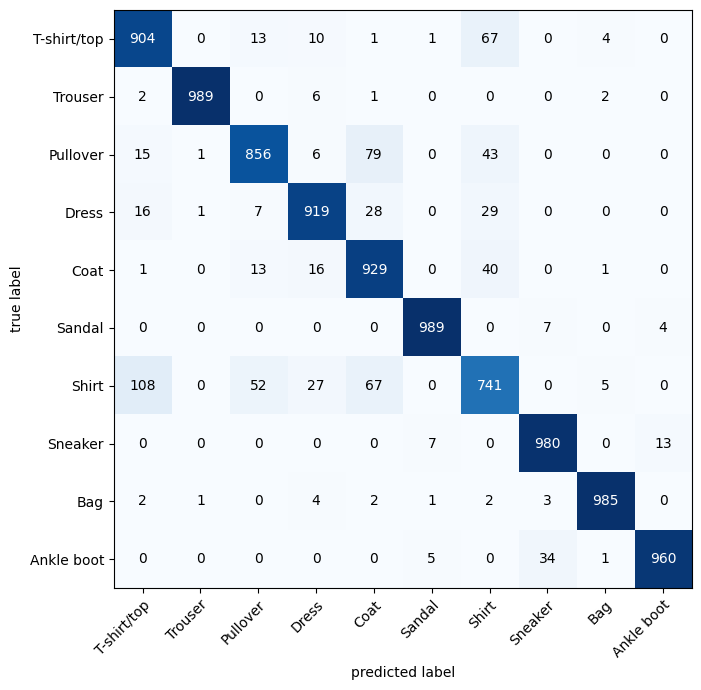


Confusion Matrix Statistics:
Shape: torch.Size([10, 10])
Total predictions: 10000

Per-class accuracy:
T-shirt/top: 0.904 (90.4%)
Trouser: 0.989 (98.9%)
Pullover: 0.856 (85.6%)
Dress: 0.919 (91.9%)
Coat: 0.929 (92.9%)
Sandal: 0.989 (98.9%)
Shirt: 0.741 (74.1%)
Sneaker: 0.980 (98.0%)
Bag: 0.985 (98.5%)
Ankle boot: 0.960 (96.0%)

Overall accuracy: 0.925 (92.5%)

Misclassified examples analysis:
Total misclassified: 748


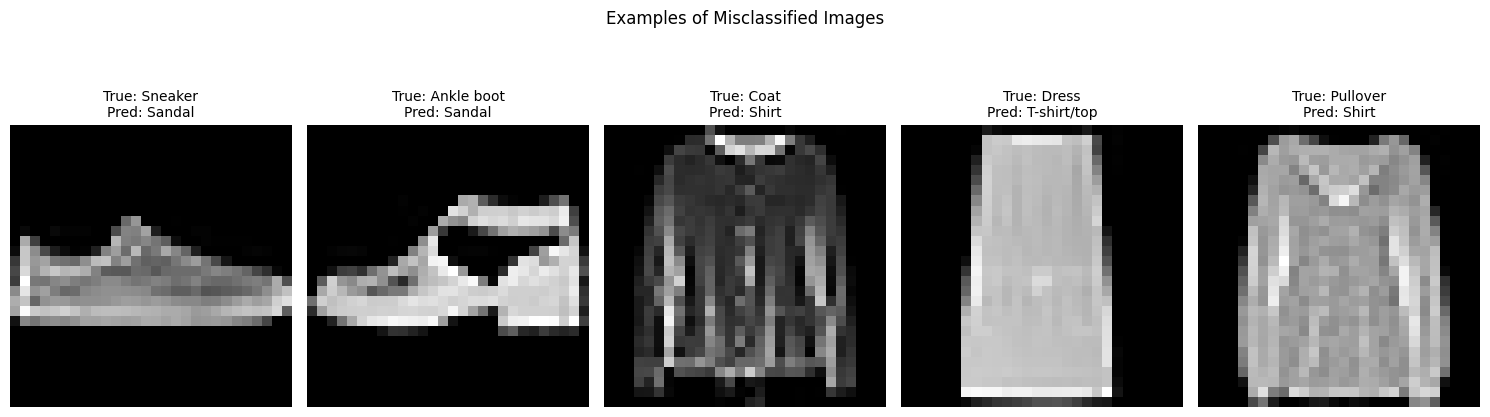

In [40]:
# 1. Make predictions with model_2 on the entire test dataset
def make_predictions_batch(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader, device: torch.device):
    """Make predictions on entire dataset using dataloader"""
    model.eval()
    predictions = []
    
    with torch.inference_mode():
        for X, y in dataloader:
            # Send data to device
            X = X.to(device)
            
            # Forward pass
            pred_logits = model(X)
            
            # Convert to prediction labels
            pred_labels = torch.argmax(pred_logits, dim=1)
            
            # Move to CPU and store
            predictions.extend(pred_labels.cpu().tolist())
    
    return torch.tensor(predictions)

# Generate predictions for all test data
print("Making predictions on test dataset...")
y_pred_tensor = make_predictions_batch(model=model_2, dataloader=test_dataloader, device=device)

print(f"Prediction tensor shape: {y_pred_tensor.shape}")
print(f"Test targets shape: {test_data.targets.shape}")

from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix
import random

# 2. Setup confusion matrix instance and compare predictions to targets
confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

# 3. Plot the confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(), # matplotlib likes working with NumPy 
    class_names=class_names, # turn the row and column labels into class names
    figsize=(10, 7)
)

plt.tight_layout()
plt.show()

# 4. Print some statistics
print(f"\nConfusion Matrix Statistics:")
print(f"Shape: {confmat_tensor.shape}")
print(f"Total predictions: {confmat_tensor.sum()}")

# Calculate per-class accuracy
class_accuracies = confmat_tensor.diag() / confmat_tensor.sum(dim=1)
print(f"\nPer-class accuracy:")
for i, (class_name, accuracy) in enumerate(zip(class_names, class_accuracies)):
    print(f"{class_name}: {accuracy:.3f} ({accuracy*100:.1f}%)")

# Overall accuracy
overall_accuracy = confmat_tensor.diag().sum() / confmat_tensor.sum()
print(f"\nOverall accuracy: {overall_accuracy:.3f} ({overall_accuracy*100:.1f}%)")

# 5. Show some misclassified examples
print(f"\nMisclassified examples analysis:")
misclassified_indices = (y_pred_tensor != test_data.targets).nonzero().flatten()
print(f"Total misclassified: {len(misclassified_indices)}")

if len(misclassified_indices) > 0:
    # Show a few misclassified examples
    plt.figure(figsize=(15, 5))
    for i in range(min(5, len(misclassified_indices))):
        idx = misclassified_indices[i].item()
        image = test_data.data[idx]
        true_label = test_data.targets[idx].item()
        pred_label = y_pred_tensor[idx].item()
        
        plt.subplot(1, 5, i+1)
        plt.imshow(image, cmap='gray')
        plt.title(f'True: {class_names[true_label]}\nPred: {class_names[pred_label]}', fontsize=10)
        plt.axis('off')
    
    plt.suptitle('Examples of Misclassified Images')
    plt.tight_layout()
    plt.show()